In [1]:
# !pip install -U pip && pip uninstall -y tensorflow && pip install tensorflow-cpu

In [2]:
## -- Check for 3rd party libraries --
try:
    from bartz.BART import gbart
    import pytabkit, jax
    from skrub import TableVectorizer
except:
    %pip install -q bartz && jax[cuda12]>=0.5.3
    %pip install -qq pytabkit
    %pip install -q skrub

    from bartz.BART import gbart
    import pytabkit, jax
    from skrub import TableVectorizer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.1/66.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.2/181.2 kB 10.0 MB/s eta 0:00:00
/bin/bash: line 1: jax[cuda12]: command not found
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.0/364.0 kB 11.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 499.4/499.4 kB 13.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic for GPU --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
    # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    # from cuml.preprocessing import TargetEncoder as cuTE
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")

ℹ️ Device GPU: Tesla P100-PCIE-16GB
ℹ️ No. of CPU: 4 cores


In [4]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
from time import time, sleep
from tqdm.notebook import tqdm
from itertools import combinations, product

## -- Machine Learning --
from pytabkit import (
        RealMLP_TD_Regressor,
        TabM_D_Regressor,
        XGB_TD_Regressor,
        LGBM_TD_Regressor,
        CatBoost_TD_Regressor,
)

import sklearn
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import root_mean_squared_error, PredictionErrorDisplay

import warnings

print('📚 Libraries imported')

📚 Libraries imported


In [5]:
## -- Global Settings --
# sklearn.set_config(transform_output="pandas")
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
plt.style.use("ggplot")
# sns.set_style("whitegrid")
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
PALETTE = ['c', 'r', 'orange']

## -- Set Global Seed --
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

COLOR = '\033[32m'
RESET = '\033[0m'

print('⚙️ Functionalities set')
# from google.colab import data_table
# data_table.enable_dataframe_formatter()

⚙️ Functionalities set


In [6]:
# ## -- Load data from Colab --
# from google.colab import drive
# drive.mount('/content/drive')

# PATH = '/content/drive/MyDrive/--colab--notebooks--/Ps6e1 | Student Test Score/student_test_dataset/'
# submit = pd.read_csv(PATH+'sample_submission.csv')
# train = pd.read_csv(PATH+'train.csv').drop('id', axis=1)
# test = pd.read_csv(PATH+'test.csv').drop('id', axis=1)
# orig = pd.read_csv(PATH+'Exam_Score_Prediction.csv').drop('student_id', axis=1)

# TARGET = train.columns[-1]
# NUMS = test.select_dtypes(include='number').columns.tolist()
# CATS = test.select_dtypes(exclude='number').columns.tolist()
# BASE = NUMS + CATS

# for (name, df) in dict(Train=train, Test=test, Original=orig).items():
#     print(f"{name} shape: {df.shape}")

# print(f"\nTotal Numerical: {len(NUMS)}")
# print(f"Total Categorical: {len(CATS)}")
# print(f"Total base features: {len(BASE)}")

In [7]:
## -- Load Data on kaggle --
PATH = '/kaggle/input/playground-series-s6e1/'
submit = pd.read_csv(PATH+'sample_submission.csv')
train = pd.read_csv(PATH+'train.csv').drop('id', axis=1)
test = pd.read_csv(PATH+'test.csv').drop('id', axis=1)

TARGET = train.columns[-1]
NUMS = test.select_dtypes(include='number').columns.tolist()
CATS = test.select_dtypes(exclude='number').columns.tolist()
BASE = NUMS + CATS

ORIG_PATH = '/kaggle/input/exam-score-prediction-dataset/'
orig = pd.read_csv(ORIG_PATH+'Exam_Score_Prediction.csv').drop('student_id', axis=1)

for (name, df) in dict(Train=train, Test=test, Original=orig).items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (630000, 12)
Test shape: (270000, 11)
Original shape: (20000, 12)

Total Numerical: 4
Total Categorical: 7
Total base features: 11


In [8]:
# ## -- Check if id is unique --
# print(f"Train ID column is Unique: {train.id.is_unique}")
# print(f"Test ID column is Unique: {test.id.is_unique}")

In [9]:
display(train.head())
train.info()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   age               630000 non-null  int64  
 1   gender            630000 non-null  object 
 2   course            630000 non-null  object 
 3   study_hours       630000 non-null  float64
 4   class_attendance  630000 non-null  float64
 5   internet_access   630000 non-null  object 
 6   sleep_hours       630000 non-null  float64
 7   sleep_quality     630000 non-null  object 
 8   study_method      630000 non-null  object 
 9   facility_rating   630000 non-null  object 
 10  exam_difficulty   630000 non-null  object 
 11  exam_score        630000 non-null  float64
dtypes: float64(4), int64(1), object(7)
memory usage: 57.7+ MB


## FEATURE ENGINEERING

In [10]:
# ## -- Factorize using combined data --
# for c in CATS_2:
#     combine  = pd.concat([train[c], test[c], orig[c]])
#     combine  = combine.factorize()[0]
#     train[c] = combine[:len(train)]
#     test[c]  = combine[len(train):len(train)+len(test)]
#     orig[c]  = combine[-len(orig):]

# ## -- Treat age(8 unique values) as category --
# NUMS.remove('age')
# CATS.append('age')

# print('Label encoding complete!')

In [11]:
## -- Create 'meta' feature --
## -- https://www.kaggle.com/competitions/playground-series-s6e1/discussion/665915
def meta_feature(df):
    formula = (
        6 * df.study_hours + \
        0.35 * df.class_attendance + \
        1.5 * df.sleep_hours + \
        5 * (df.sleep_quality=='good') + \
        -5 * (df.sleep_quality=='poor') + \
        10 * (df.study_method=='coaching') + \
        5 * (df.study_method=='mixed') + \
        2 * (df.study_method=='group study') + \
        1 * (df.study_method=='online videos') + \
        4 * (df.facility_rating=='high') + \
        -4 * (df.facility_rating=='low')
    )
    return formula

train['formula'] = meta_feature(train)
test['formula'] = meta_feature(test)
orig['formula'] = meta_feature(orig)


## -- Set ordinal mapping --
ordinal_maps = {
    "internet_access": {"no":0, "yes":1},
    "gender": {"male":0, "female":1, "other":2},
    "sleep_quality": {"poor":0, "average":1, "good":2},
    "facility_rating": {"low":0, "medium":1, "high":2},
    "exam_difficulty": {"easy":0, "moderate":1, "hard":2},
    "course": {"ba":0, "b.sc":1, "diploma":2, "b.tech":3, "b.com":4, "bca":5, "bba":6},
    "study_method": {"self-study":0, "online videos":1, "group study":2, "mixed":3, "coaching":4},
}

for c in CATS:
    train[c] = train[c].map(ordinal_maps[c]).fillna(-1)
    test[c] = test[c].map(ordinal_maps[c]).fillna(-1)
    orig[c] = orig[c].map(ordinal_maps[c]).fillna(-1)

print("Feature 'formula' created. Ordinal mapping complete")
train.head()

Feature 'formula' created. Ordinal mapping complete


,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score,formula
0,21,1,1,7.91,98.8,0,4.9,1,1,0,0,78.3,86.390
1,18,2,2,4.95,94.8,1,4.7,0,0,1,1,46.7,64.930
2,20,1,1,4.68,92.6,1,5.8,0,4,2,1,99.0,78.190
3,19,0,1,2.00,49.5,1,8.3,1,2,2,1,63.9,47.775
4,23,0,5,7.65,86.9,1,9.6,2,0,2,0,100.0,99.715


In [12]:
# for df_temp in [train, test, orig]:

#     # df_temp['study_hours_squared'] = df_temp['study_hours'] ** 2
#     # df_temp['study_hours_cubed'] = df_temp['study_hours'] ** 3
#     # df_temp['class_attendance_squared'] = df_temp['class_attendance'] ** 2
#     # df_temp['sleep_hours_squared'] = df_temp['sleep_hours'] ** 2
#     # df_temp['age_squared'] = df_temp['age'] ** 2

#     # df_temp['log_study_hours'] = np.log1p(df_temp['study_hours'])
#     # df_temp['log_class_attendance'] = np.log1p(df_temp['class_attendance'])
#     # df_temp['log_sleep_hours'] = np.log1p(df_temp['sleep_hours'])
#     # df_temp['sqrt_study_hours'] = np.sqrt(df_temp['study_hours'])
#     # df_temp['sqrt_class_attendance'] = np.sqrt(df_temp['class_attendance'])

#     ## -- Interaction features --
#     # df_temp['study_hours_times_attendance'] = df_temp['study_hours'] * df_temp['class_attendance']
#     # df_temp['study_hours_times_sleep'] = df_temp['study_hours'] * df_temp['sleep_hours']
#     # df_temp['attendance_times_sleep'] = df_temp['class_attendance'] * df_temp['sleep_hours']

#     ## -- Ratio features (add small epsilon to avoid division by zero) --
#     # eps = 1e-6
#     # df_temp['study_hours_over_sleep'] = df_temp['study_hours'] / (df_temp['sleep_hours'] + eps)
#     # df_temp['attendance_over_sleep'] = df_temp['class_attendance'] / (df_temp['sleep_hours'] + eps)

#     ## -- Feature by: Vladimir Demidov
#     ## -- https://www.kaggle.com/competitions/playground-series-s6e1/discussion/665915
#     LUT = {
#         'sleep_quality': {'good': 5, 'average': 0, 'poor': -5},
#         'facility_rating': {'high': 4, 'medium': 0, 'low': -4},
#         'study_method': {
#             'coaching': 10,
#             'mixed': 5,
#             'group study': 2,
#             'online videos': 1,
#             'self-study': 0
#         }
#     }

#     df_temp['formula'] = 6 * df_temp['study_hours'] + 0.35 * df_temp['class_attendance'] \
#             + 1.5 * df_temp['sleep_hours'] + \
#             + df_temp['sleep_quality'].map(LUT['sleep_quality']) \
#             + df_temp['study_method'].map(LUT['study_method']) \
#             + df_temp['facility_rating'].map(LUT['facility_rating'])

#     ## -- Encode categorical variables to numeric ordinal values --
#     ordinal_maps = {
#         "internet_access": {"no":0, "yes":1},
#         "gender": {"male":0, "female":1, "other":2},
#         "sleep_quality": {"poor":0, "average":1, "good":2},
#         "facility_rating": {"low":0, "medium":1, "high":2},
#         "exam_difficulty": {"easy":0, "moderate":1, "hard":2},
#         "course": {"ba":0, "b.sc":1, "diploma":2, "b.tech":3, "b.com":4, "bca":5, "bba":6},
#         "study_method": {"self-study":0, "online videos":1, "group study":2, "mixed":3, "coaching":4},
#     }

#     for c in CATS:
#         df_temp[c] = df_temp[c].map(ordinal_maps[c]).fillna(-1)

#     ## -- Interaction between encoded categoricals and key numeric features --
#     # df_temp['study_hours_times_sleep_quality'] = df_temp['study_hours'] * df_temp['sleep_quality']
#     # df_temp['attendance_times_facility'] = df_temp['class_attendance'] * df_temp['facility_rating']
#     # df_temp['sleep_hours_times_difficulty'] = df_temp['sleep_hours'] * df_temp['exam_difficulty']
#     # df_temp['age_times_study_hours'] = df_temp['age'] * df_temp['study_hours']
#     # df_temp['age_times_attendance'] = df_temp['age'] * df_temp['class_attendance']

#     # ## -- Composite feature: learning efficiency --
#     # df_temp['efficiency'] = (df_temp['study_hours'] * df_temp['class_attendance']) / (df_temp['sleep_hours'] + 1)
#     # df_temp["study_efficiency"] = df_temp["study_hours"] * (df_temp["class_attendance"] / 100.0)

#     # ## -- Cyclic encoding --
#     # for p in [12, 14]:
#     #     df_temp[f"study_hours_sin_{p}"] = np.sin(2 * np.pi * df_temp['study_hours'] / p).astype('float32')
#     #     df_temp[f"class_attend_sin_{p}"] = np.sin(2 * np.pi * df_temp['class_attendance'] / p).astype('float32')

#     total_features = [c for c in df_temp.columns if c != TARGET]
#     print(f'Feature Engineered: {len(total_features)}')

In [13]:
## -- Duplicate all features as categories --
CATS_2 = []
for c in BASE:
    n = f"cat_{c}"
    train[n] = train[c].copy()
    test[n] = test[c].copy()
    orig[n] = orig[c].copy()
    CATS_2.append(n)

## -- Factorize using combined data --
    combine  = pd.concat([train[n], test[n], orig[n]])
    v = combine.factorize()[0]
    train[n] = v[:len(train)]
    test[n]  = v[len(train):len(train)+len(test)]
    orig[n]  = v[len(train)+len(test):]

print('CATS_2 - Label encoding complete!')
train.head()

CATS_2 - Label encoding complete!


,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score,formula,cat_age,cat_study_hours,cat_class_attendance,cat_sleep_hours,cat_gender,cat_course,cat_internet_access,cat_sleep_quality,cat_study_method,cat_facility_rating,cat_exam_difficulty
0,21,1,1,7.91,98.8,0,4.9,1,1,0,0,78.3,86.390,0,0,0,0,0,0,0,0,0,0,0
1,18,2,2,4.95,94.8,1,4.7,0,0,1,1,46.7,64.930,1,1,1,1,1,1,1,1,1,1,1
2,20,1,1,4.68,92.6,1,5.8,0,4,2,1,99.0,78.190,2,2,2,2,0,0,1,1,2,2,1
3,19,0,1,2.00,49.5,1,8.3,1,2,2,1,63.9,47.775,3,3,3,3,2,0,1,0,3,2,1
4,23,0,5,7.65,86.9,1,9.6,2,0,2,0,100.0,99.715,4,4,4,4,2,2,1,2,1,2,0


In [14]:
TOP_PREDICTORS = ['study_hours', 'class_attendance']
OTHER_PREDICTORS = [c for c in BASE if c not in TOP_PREDICTORS]

print('Feature sets defined!')

Feature sets defined!


In [15]:
## -- Extract Digits --
DIGITS = []

for col in tqdm(TOP_PREDICTORS+['sleep_hours', 'formula']):
    for d in range(-2, 4):
        n = f'{col}_d{d}'
        train[n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
        test[n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
        orig[n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int32')

        ## -- Drop constant features --
        if train[n].nunique() < 2:
            train.drop([n], axis=1, inplace=True)
            test.drop([n],  axis=1, inplace=True)
            orig.drop([n],  axis=1, inplace=True)
        else:
            DIGITS.append(n)

print(f'{len(DIGITS)} Feature DIGITS extracted.')
print(train[DIGITS].nunique())

  0%|          | 0/4 [00:00<?, ?it/s]

18 Feature DIGITS extracted.
study_hours_d0           8
study_hours_d1          10
study_hours_d2          10
study_hours_d3           7
class_attendance_d-1     6
class_attendance_d0     10
class_attendance_d1     10
class_attendance_d2     10
class_attendance_d3      3
sleep_hours_d0           6
sleep_hours_d1          10
sleep_hours_d2           5
formula_d-2              2
formula_d-1             10
formula_d0              10
formula_d1              10
formula_d2              10
formula_d3              10
dtype: int64


In [16]:
# ## -- Reduce data memory --
# def reduce_memory(df):
#     old_size = sys.getsizeof(df) / (1024*1024)
#     for c in tqdm(df.columns, desc='Reducing memory...'):
#         ## -- Downcast Integer type --
#         if df[c].dtype == np.int64:
#             if df[c].min() > np.iinfo(np.int32).min and df[c].max() < np.iinfo(np.int32).max:
#                 df[c] = df[c].astype(np.int32)
#                 # if df[c].min() > np.iinfo(np.int16).min and df[c].max() < np.iinfo(np.int16).max:
#                 #     df[c] = df[c].astype(np.int16)
#                 #     if df[c].min() > np.iinfo(np.int8).min and df[c].max() < np.iinfo(np.int8).max:
#                 #         df[c] = df[c].astype(np.int8)
#         ## -- Downcast Float type --
#         # elif df[c].dtype == np.float64:
#         #     if df[c].min() > np.finfo(np.float32).min and df[c].max() < np.finfo(np.float32).max:
#         #         df[c] = df[c].astype(np.float32)
#                 # if df[c].min() > np.finfo(np.float16).min and df[c].max() < np.finfo(np.float16).max:
#                 #     df[c] = df[c].astype(np.float16)

#     new_size = sys.getsizeof(df) / (1024*1024)
#     print(f"Size before process: {old_size:.1f}MB")
#     print(f"Size after process : {new_size:.1f}MB\n")

#     return df

# train = reduce_memory(train)
# test  = reduce_memory(test)
# orig  = reduce_memory(orig)

# gc.collect()

# print(f"Dataset size reduced!")

In [17]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

# ML TRAINING

In [18]:
# tab_params = {
#     'batch_size': 2048,
#     'lr': 0.1,
#     'tabm_k': 24,
#     'n_epochs': 50,
#     'patience': 4,
#     'arch_type': 'tabm-mini',
#     'verbosity': 0,
#     'random_state': SEED,
# }
tab_params = {
    'verbosity': 2,
    'arch_type': 'tabm-mini-normal',
    'tabm_k': 24,
    'num_emb_type': 'pwl',
    'd_embedding': 8,
    'batch_size': 256,
    'lr': 1e-3,
    'n_epochs': 100,
    'dropout': 0.11,
    'd_block': 256,
    'n_blocks': 5,
    'patience': 5,
    'weight_decay': 1e-2,
    # 'device': 'gpu' if torch.cuda.is_available() else 'cpu',
    'random_state': SEED,
}

params = {
    'maxdepth': 6,
    'ntree': 2000,
    'k': 4.0,
    # 'sigdf': 3.0,
    # 'sigquant': 0.9,
    # 'ndpost': 2000,
    # 'nskip': 200,
    # 'keepevery': 2,
    'printevery': 100,
    'seed': SEED,
}

In [19]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('Total Features:', len(FEATURES))

train.head(3)

Total Features: 41


,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score,formula,cat_age,cat_study_hours,cat_class_attendance,cat_sleep_hours,cat_gender,cat_course,cat_internet_access,cat_sleep_quality,cat_study_method,cat_facility_rating,cat_exam_difficulty,study_hours_d0,study_hours_d1,study_hours_d2,study_hours_d3,class_attendance_d-1,class_attendance_d0,class_attendance_d1,class_attendance_d2,class_attendance_d3,sleep_hours_d0,sleep_hours_d1,sleep_hours_d2,formula_d-2,formula_d-1,formula_d0,formula_d1,formula_d2,formula_d3
0,21,1,1,7.91,98.8,0,4.9,1,1,0,0,78.3,86.39,0,0,0,0,0,0,0,0,0,0,0,7,9,1,0,9,8,8,0,0,4,9,0,0,8,6,3,8,9
1,18,2,2,4.95,94.8,1,4.7,0,0,1,1,46.7,64.93,1,1,1,1,1,1,1,1,1,1,1,4,9,5,0,9,4,8,0,0,4,7,0,0,6,4,9,3,0
2,20,1,1,4.68,92.6,1,5.8,0,4,2,1,99.0,78.19,2,2,2,2,0,0,1,1,2,2,1,4,6,8,0,9,2,6,0,0,5,8,0,0,7,8,1,9,0



##### FOLD 1/8
####################
CategoryMeanEncoding: 25 | Columns classified as continuous: ['age', 'gender', 'course', 'study_hours', 'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty', 'formula']
Columns classified as categorical: ['cat_age', 'cat_study_hours', 'cat_class_attendance', 'cat_sleep_hours', 'cat_gender', 'cat_course', 'cat_internet_access', 'cat_sleep_quality', 'cat_study_method', 'cat_facility_rating', 'cat_exam_difficulty', 'study_hours_d0', 'study_hours_d1', 'study_hours_d2', 'study_hours_d3', 'class_attendance_d-1', 'class_attendance_d0', 'class_attendance_d1', 'class_attendance_d2', 'class_attendance_d3', 'sleep_hours_d0', 'sleep_hours_d1', 'sleep_hours_d2', 'formula_d-2', 'formula_d-1', 'formula_d0', 'formula_d1', 'formula_d2', 'formula_d3']
Device:        CUDA
AMP:           False (dtype: torch.bfloat16)
torch.compile: False
--------------------------------------------------------------

Epoch 0: 100%|██████████| 2232/2232 [00:20<00:00, 107.81it/s]


(val) -8.6309
🌸 New best epoch! 🌸



Epoch 1: 100%|██████████| 2232/2232 [00:20<00:00, 109.79it/s]


(val) -8.5930
🌸 New best epoch! 🌸



...

(val) -8.6358



Epoch 9: 100%|██████████| 2232/2232 [00:20<00:00, 109.87it/s]


(val) -8.6457



Epoch 10: 100%|██████████| 2232/2232 [00:20<00:00, 109.84it/s]


(val) -8.6633


Result:
{'val': -8.612262725830078, 'epoch': 4}
Restoring best model
-> Model_1 -> tabM RMSE: 8.61226
....................................................................................................
It 100/1100 grow P=52% A=16%, prune P=48% A=17%, fill=7% (burnin)
....................................................................................................
It 200/1100 grow P=50% A=14%, prune P=50% A=15%, fill=8%
....................................................................................................
It 300/1100 grow P=52% A=14%, prune P=48% A=14%, fill=8%
....................................................................................................
It 400/1100 grow P=52% A=14%, prune P=48% A=14%, fill=8%
....................................................................................................
It 500/1100 grow P=52% A=15%, prune P=48% A=12%, fill=8%
...................................................................................

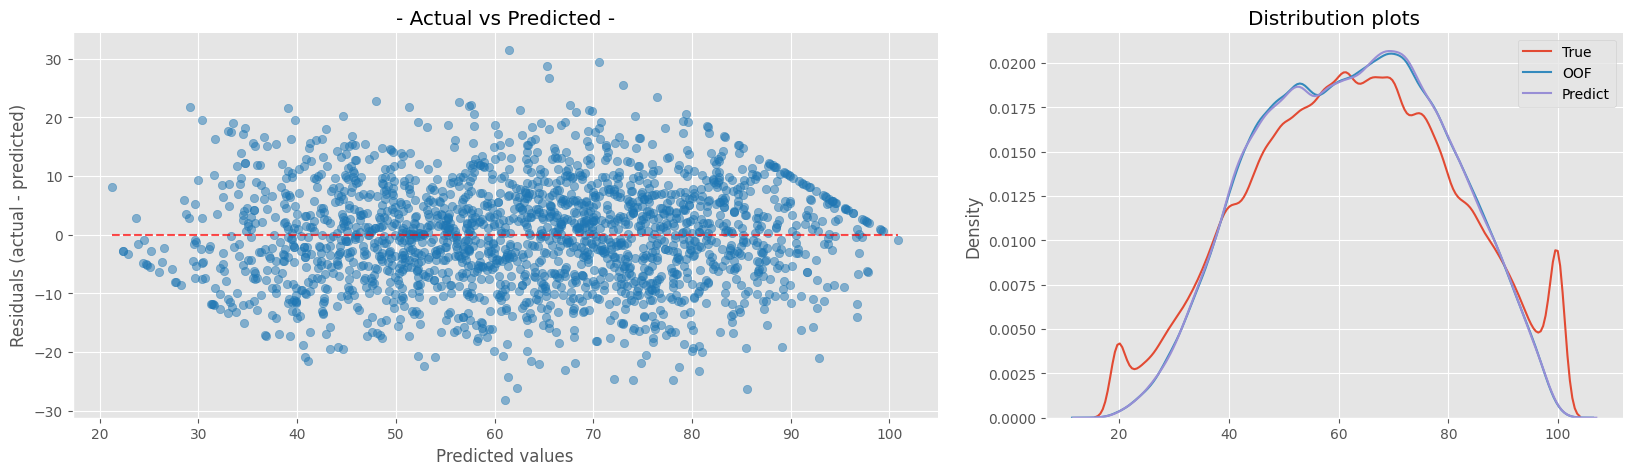

Training Time: 83.93 mins =========================
|--------------------------------------------------

Saving/Submission #####



,id,exam_score
0,630000,69.557053
1,630001,68.646309
2,630002,89.441544
3,630003,55.945210
4,630004,45.394310


In [20]:
## -- Define BARTZ over NN --
X = train[FEATURES]
X_orig = orig[FEATURES]

y = train[TARGET].values
y_orig = orig[TARGET].values

kf = KFold(n_splits=8, shuffle=True, random_state=SEED)

oof_preds  = np.zeros(len(X))
test_preds = np.zeros(len(test))
fold_scores = []

## -- Initiate Training --
tik = time()
for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"\n{'#'*5} FOLD {fold+1}/{kf.n_splits}")
    print(f"{'#'*20}")

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    X_test = test[FEATURES].copy()

    ## -- Concatenate original data when not using base_score --
    X_train = pd.concat([X_train, X_orig], ignore_index=True)
    y_train = np.concatenate([y_train, y_orig], axis=0)

    # ## -- TE Opt1. -> Using CUSTOM
    # TE = TargetEncoder(ROUND, cv=5, smooth=0.05, aggs=['mean'], drop_original=True)
    # X_train = TE.fit_transform(X_train, pd.Series(y_train))
    # X_val   = TE.transform(X_val)
    # X_test  = TE.transform(X_test)

    ## -- CME for DIGITS & CATS --
    cme_cat_cols = []
    print(f"CategoryMeanEncoding: {len(DIGITS+CATS)} | ", end='')
    for c in DIGITS+CATS:
        # n = f"CME_{c}"
        CME = CategoryMeanTransformer(cat_cols=[c])
        X_train[c] = CME.fit_transform(X_train[[c]], y_train.reshape(-1, )).fillna(-1)
        X_val[c]   = CME.transform(X_val[[c]]).fillna(-1)
        X_test[c]  = CME.transform(X_test[[c]]).fillna(-1)
        # cme_cat_cols.append(n)

    # for c in CATS+['age']:
    #     CME = CategoryMeanTransformer(cat_cols=[c])
    #     X_train[c] = CME.fit_transform(X_train[[c]], y_train.reshape(-1, )).astype('float32')
    #     X_val[c]   = CME.transform(X_val[[c]]).astype('float32')
    #     X_test[c]  = CME.transform(X_test[[c]]).astype('float32')

    ## -- Train Stage1 model: NN --
    m1 = 'tabM'
    model_1 = TabM_D_Regressor(**tab_params)
    # model_1 = RealMLP_TD_Regressor(random_state=SEED)

    model_1.fit(X_train, y_train, X_val, y_val, cat_col_names=CATS_2+DIGITS)
    oof_m1 = model_1.predict(X_val)
    test_m1 = model_1.predict(X_test)

    print(f"-> Model_1 -> {m1} RMSE: {root_mean_squared_error(y_val, oof_m1):.5f}")

    ## -- PSEUDO LABELS FROM model_1 AS FEATURES FOR model_2 --
    X_train_full = pd.concat([X_train, X_val, X_test], ignore_index=True).copy()
    y_train_full = np.concatenate([y_train, oof_m1, test_m1], axis=0)

    for c in CATS_2 + DIGITS:
        X_train_full[c] = X_train_full[c].astype('category')

    X_val_2  = X_train_full.iloc[len(X_train):len(X_train)+len(X_val)]
    X_test_2 = X_train_full.iloc[len(X_train)+len(X_val):]

    m2 = 'bartz'
    model_2 = gbart(X_train_full.to_numpy().T, y_train_full, **params)

    oof_preds[val_idx] = model_2.predict(X_val_2.to_numpy().T).mean(axis=0).ravel()
    test_preds += model_2.predict(X_test_2.to_numpy().T).mean(axis=0).ravel()

    fold_rmse = root_mean_squared_error(y_val, oof_preds[val_idx])
    fold_scores.append(fold_rmse)

    print(f"-> Model_2 -> {m2} RMSE: {fold_rmse:.5f}")

    gc.collect()
    torch.cuda.empty_cache()

## -- After all folds --
test_preds /= kf.n_splits

overall_score = np.round(root_mean_squared_error(y, oof_preds), 5)
print(f"|{'-'*50}{COLOR}")
print(f"|  DATASET: {X_train_full.shape}")
print(f"| OOF RMSE: {overall_score}")
print(f"| AVG RMSE: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}{RESET}")

## -- Plot predictions errors --
_, axs = plt.subplots(1, 2, figsize=(20, 5), gridspec_kw={'width_ratios':[0.6, 0.4], 'wspace':0.15})
display = PredictionErrorDisplay.from_predictions(
    y,
    oof_preds,
    ax=axs[0],
    subsample=2000,
    # kind = "actual_vs_predicted",
    scatter_kwargs={"alpha": 0.5}, line_kwargs={'color': 'r'},
)
axs[0].set_title(f"- Actual vs Predicted -")

LABELS = ['True', 'OOF', 'Predict']
sns.kdeplot(y, ax=axs[1], label=LABELS[0])
sns.kdeplot(oof_preds, ax=axs[1], label=LABELS[1])
sns.kdeplot(test_preds, ax=axs[1], label=LABELS[2])
axs[1].set_title(f"Distribution plots")

for ax in axs:
    # ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.legend()
plt.tight_layout()
plt.show()

tok = time()
tiktok = (tok-tik) / 60
print(f"Training Time: {tiktok:.2f} mins {'='*25}")
print(f"|{'-'*50}\n")

## ---------- SAVE/SUBMISSION -------------------------------
print(f"Saving/Submission {'#'*5}\n")

name = f"{m2}_{m1}_pseudo_" + f"{overall_score}".split('.')[1]
oof_final = pd.DataFrame(oof_preds, columns=[name])
test_final = pd.DataFrame(test_preds, columns=[name])

## -- Save OOF & PREDICTIONS --
oof_final.to_parquet(f"oof_{name}.parquet", index=False)
test_final.to_parquet(f"test_{name}.parquet", index=False)

## -- Submission file --
submit[TARGET] = np.clip(test_final.values, min(y), max(y))
submit.to_csv(f"submit_{name}.csv", index=False)
submit.head()

In [21]:
float(overall_score), oof_final.shape, test_final.shape

(8.65653, (630000, 1), (270000, 1))

In [22]:
oof_final.head(), test_final.head()

(   bartz_tabM_pseudo_65653
 0                85.914291
 1                61.573631
 2                73.660393
 3                46.667362
 4                97.133286,
    bartz_tabM_pseudo_65653
 0                69.557053
 1                68.646309
 2                89.441544
 3                55.945210
 4                45.394310)